# Find Co-ordinates of Contours

In [2]:
import numpy as np
import cv2

font = cv2.FONT_HERSHEY_COMPLEX

# Load image
img2 = cv2.imread('image.png', cv2.IMREAD_COLOR)
img = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)

# Binarize image
_, threshold = cv2.threshold(img, 110, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    approx = cv2.approxPolyDP(cnt, 0.009 * cv2.arcLength(cnt, True), True)
    cv2.drawContours(img2, [approx], 0, (0, 0, 255), 5)

    n = approx.ravel()
    for i in range(0, len(n), 2):
        x, y = n[i], n[i+1]
        coord = f"{x} {y}"
        if i == 0:
            cv2.putText(img2, "Arrow tip", (x, y), font, 0.5, (255, 0, 0))
        else:
            cv2.putText(img2, coord, (x, y), font, 0.5, (0, 255, 0))

# Show result
cv2.imshow('Contours with Coordinates', img2)

# Exit on 'q'
if cv2.waitKey(0) & 0xFF == ord('q'):
    cv2.destroyAllWindows()

# Analyze an image using Histogram

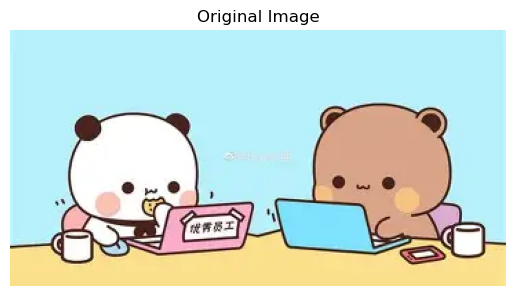

In [17]:
import cv2
from matplotlib import pyplot as plt

# Load image using OpenCV
img = cv2.imread('image.png')  # reads the image regardless of extension
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR -> RGB for matplotlib

# Display
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

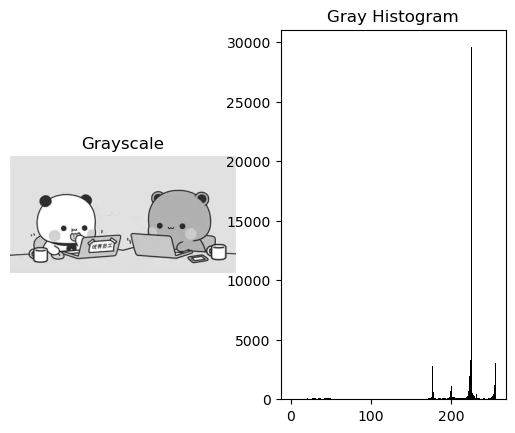

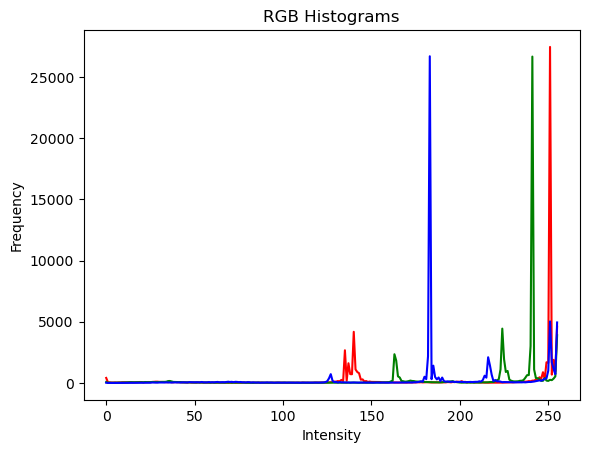

In [7]:
import cv2, matplotlib.pyplot as plt
img = cv2.imread("image.png")

# Grayscale + Histogram
g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.subplot(121), plt.imshow(g, cmap='gray'), plt.axis("off"), plt.title("Grayscale")
plt.subplot(122), plt.hist(g.ravel(),256,[0,256],color='k'), plt.title("Gray Histogram")
plt.show()

# RGB Histograms
for i,c in enumerate(('r','g','b')):
    plt.plot(cv2.calcHist([img],[i],None,[256],[0,256]), color=c)
plt.title("RGB Histograms"), plt.xlabel("Intensity"), plt.ylabel("Frequency")
plt.show()

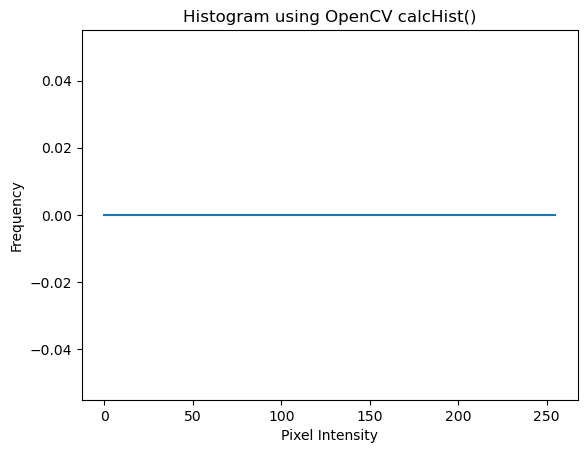

In [10]:
img = cv2.imread('image.jpg', 0)
histg = cv2.calcHist([img], [0], None, [256], [0, 256])

# Plot histogram
plt.plot(histg)
plt.title("Histogram using OpenCV calcHist()")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

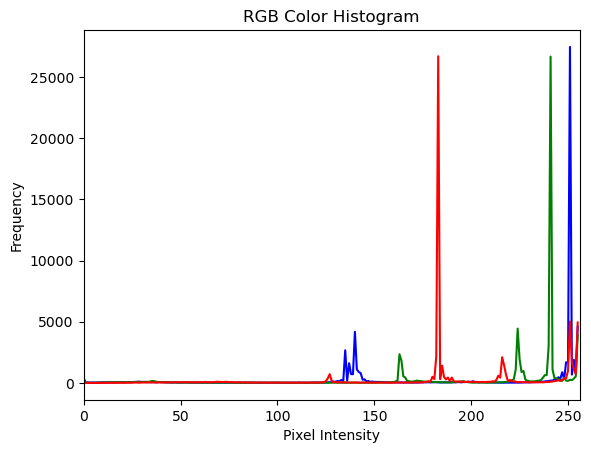

In [12]:
img = cv2.imread('image.png')

# colors for channels
colors = ('b', 'g', 'r')

for i, col in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    plt.xlim([0, 256])

plt.title("RGB Color Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

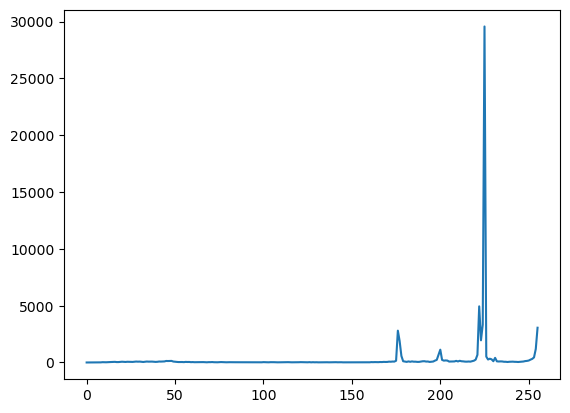

In [14]:
import cv2
from matplotlib import pyplot as plt
img = cv2.imread('image.png',0)

histr = cv2.calcHist([img],[0],None,[256],[0,256])
plt.plot(histr)
plt.show()

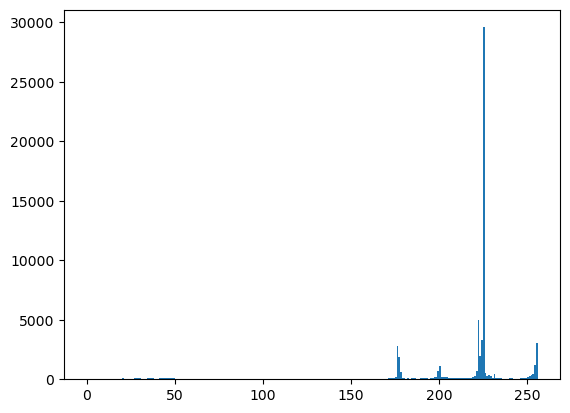

In [15]:
import cv2
from matplotlib import pyplot as plt
img = cv2.imread('image.png',0)

# alternative way to find histogram of an image
plt.hist(img.ravel(),256,[0,256])
plt.show()